# 🔧 EDA Completo — NASA CMAPSS Turbofan Engine Dataset
**Objetivo:** Análisis Exploratorio de Datos para predecir la Vida Útil Restante (RUL) de motores turbofan

**Dataset:** NASA CMAPSS — Datos reales de sensores de motores de avión

---
## Índice
1. Obtención del Dataset
2. Carga y estructura de los datos
3. Análisis de valores nulos y estadísticas básicas
4. Creación de la variable objetivo RUL
5. Distribución de variables numéricas
6. Selección de variables predictoras
7. Correlación entre variables
8. Evolución de sensores por ciclo
9. Resumen y conclusiones del EDA

---
## 📦 PASO 1 — Obtención del Dataset
Descargamos el dataset directamente desde Kaggle usando kagglehub.

In [4]:
# Instalar kagglehub si no está instalado
# !pip install kagglehub

import kagglehub
import os

# Descargar dataset
path = kagglehub.dataset_download('behrad3d/nasa-cmaps')
print(f'✅ Dataset descargado en: {path}')

# Ver archivos disponibles
print('\n📂 Archivos disponibles:')
for root, dirs, files in os.walk(path):
    for file in files:
        print(f'   {os.path.join(root, file)}')

✅ Dataset descargado en: /home/vscode/.cache/kagglehub/datasets/behrad3d/nasa-cmaps/versions/1

📂 Archivos disponibles:
   /home/vscode/.cache/kagglehub/datasets/behrad3d/nasa-cmaps/versions/1/CMaps/RUL_FD004.txt
   /home/vscode/.cache/kagglehub/datasets/behrad3d/nasa-cmaps/versions/1/CMaps/RUL_FD002.txt
   /home/vscode/.cache/kagglehub/datasets/behrad3d/nasa-cmaps/versions/1/CMaps/RUL_FD001.txt
   /home/vscode/.cache/kagglehub/datasets/behrad3d/nasa-cmaps/versions/1/CMaps/RUL_FD003.txt
   /home/vscode/.cache/kagglehub/datasets/behrad3d/nasa-cmaps/versions/1/CMaps/test_FD003.txt
   /home/vscode/.cache/kagglehub/datasets/behrad3d/nasa-cmaps/versions/1/CMaps/train_FD002.txt
   /home/vscode/.cache/kagglehub/datasets/behrad3d/nasa-cmaps/versions/1/CMaps/test_FD002.txt
   /home/vscode/.cache/kagglehub/datasets/behrad3d/nasa-cmaps/versions/1/CMaps/Damage Propagation Modeling.pdf
   /home/vscode/.cache/kagglehub/datasets/behrad3d/nasa-cmaps/versions/1/CMaps/readme.txt
   /home/vscode/.cache/k

---
## 📂 PASO 2 — Carga y Estructura de los Datos
El dataset tiene 4 subconjuntos (FD001 a FD004). Los combinamos todos para tener más de 60,000 filas y 22+ columnas.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo de gráficas
plt.style.use('seaborn-v0_8-whitegrid')


# Path de los archivos
DATA_PATH = '/home/vscode/.cache/kagglehub/datasets/behrad3d/nasa-cmaps/versions/1/CMaps'

# Nombres de columnas según documentación NASA CMAPSS
columnas = (['unit_id', 'cycle', 'op_setting_1', 'op_setting_2', 'op_setting_3'] +
            [f'sensor_{i}' for i in range(1, 22)])

# Cargar los 4 archivos de entrenamiento
df1 = pd.read_csv(f'{DATA_PATH}/train_FD001.txt', sep='\s+', header=None, names=columnas)
df2 = pd.read_csv(f'{DATA_PATH}/train_FD002.txt', sep='\s+', header=None, names=columnas)
df3 = pd.read_csv(f'{DATA_PATH}/train_FD003.txt', sep='\s+', header=None, names=columnas)
df4 = pd.read_csv(f'{DATA_PATH}/train_FD004.txt', sep='\s+', header=None, names=columnas)

# Etiquetar cada subconjunto
df1['dataset'] = 'FD001'
df2['dataset'] = 'FD002'
df3['dataset'] = 'FD003'
df4['dataset'] = 'FD004'

# Combinar todos
df = pd.concat([df1, df2, df3, df4], ignore_index=True)

print('=' * 50)
print('📊 ESTRUCTURA DEL DATASET COMBINADO')
print('=' * 50)
print(f'Filas:    {df.shape[0]:,}')
print(f'Columnas: {df.shape[1]}')
print(f'\nRegistros por subconjunto:')
print(df['dataset'].value_counts())
print(f'\nPrimeras 5 filas:')
df.head()

<>:18: SyntaxWarning: invalid escape sequence '\s'
<>:19: SyntaxWarning: invalid escape sequence '\s'
<>:20: SyntaxWarning: invalid escape sequence '\s'
<>:21: SyntaxWarning: invalid escape sequence '\s'
<>:18: SyntaxWarning: invalid escape sequence '\s'
<>:19: SyntaxWarning: invalid escape sequence '\s'
<>:20: SyntaxWarning: invalid escape sequence '\s'
<>:21: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_24337/3026998578.py:18: SyntaxWarning: invalid escape sequence '\s'
  df1 = pd.read_csv(f'{DATA_PATH}/train_FD001.txt', sep='\s+', header=None, names=columnas)
/tmp/ipykernel_24337/3026998578.py:19: SyntaxWarning: invalid escape sequence '\s'
  df2 = pd.read_csv(f'{DATA_PATH}/train_FD002.txt', sep='\s+', header=None, names=columnas)
/tmp/ipykernel_24337/3026998578.py:20: SyntaxWarning: invalid escape sequence '\s'
  df3 = pd.read_csv(f'{DATA_PATH}/train_FD003.txt', sep='\s+', header=None, names=columnas)
/tmp/ipykernel_24337/3026998578.py:21: SyntaxWarning: invalid escap

📊 ESTRUCTURA DEL DATASET COMBINADO
Filas:    160,359
Columnas: 27

Registros por subconjunto:
dataset
FD004    61249
FD002    53759
FD003    24720
FD001    20631
Name: count, dtype: int64

Primeras 5 filas:


,unit_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,dataset
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,FD001
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,FD001
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,FD001
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,FD001
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,FD001


### ℹ️ Descripción de columnas

| Columna | Descripción |
|---|---|
| unit_id | ID del motor |
| cycle | Ciclo de operación (cada vuelo = 1 ciclo) |
| op_setting_1 | Altitud de vuelo |
| op_setting_2 | Velocidad Mach |
| op_setting_3 | Temperatura del acelerador |
| sensor_1 | Temperatura entrada ventilador |
| sensor_2 | Temperatura salida compresor LPC |
| sensor_3 | Temperatura salida compresor HPC |
| sensor_4 | Temperatura salida combustión |
| sensor_5 | Presión entrada ventilador |
| sensor_6 | Presión estática salida ventilador |
| sensor_7 | Presión salida compresor HPC |
| sensor_8 | Velocidad física ventilador |
| sensor_9 | Velocidad física núcleo |
| sensor_10 | Relación de presión del motor |
| sensor_11 | Temperatura estática salida HPC |
| sensor_12 | Proporción de combustible |
| sensor_13 | Velocidad corregida ventilador |
| sensor_14 | Velocidad corregida núcleo |
| sensor_15 | Relación de presión bypass |
| sensor_16 | Relación de presión compresor HPC |
| sensor_17 | Relación de presión compresor LPC |
| sensor_18 | Temperatura de escape EGT |
| sensor_19 | Temperatura salida turbina LPT |
| sensor_20 | Vibración del motor |
| sensor_21 | Consumo de combustible |

---
## 🔍 PASO 3 — Análisis de Valores Nulos y Estadísticas Básicas

In [8]:
print('=' * 50)
print('📋 TIPOS DE DATOS')
print('=' * 50)
print(df.dtypes)

print('\n' + '=' * 50)
print('❌ VALORES NULOS')
print('=' * 50)
nulos = df.isnull().sum()
if nulos.sum() == 0:
    print('✅ No hay valores nulos en ninguna columna')
else:
    print(nulos[nulos > 0])

print('\n' + '=' * 50)
print('📈 ESTADÍSTICAS DESCRIPTIVAS')
print('=' * 50)
df.describe().round(2)

📋 TIPOS DE DATOS
unit_id           int64
cycle             int64
op_setting_1    float64
op_setting_2    float64
op_setting_3    float64
sensor_1        float64
sensor_2        float64
sensor_3        float64
sensor_4        float64
sensor_5        float64
sensor_6        float64
sensor_7        float64
sensor_8        float64
sensor_9        float64
sensor_10       float64
sensor_11       float64
sensor_12       float64
sensor_13       float64
sensor_14       float64
sensor_15       float64
sensor_16       float64
sensor_17         int64
sensor_18         int64
sensor_19       float64
sensor_20       float64
sensor_21       float64
dataset             str
dtype: object

❌ VALORES NULOS
✅ No hay valores nulos en ninguna columna

📈 ESTADÍSTICAS DESCRIPTIVAS


,unit_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
count,160359.00,160359.00,160359.00,160359.00,160359.00,160359.00,160359.00,160359.00,160359.00,160359.00,...,160359.00,160359.00,160359.00,160359.00,160359.00,160359.00,160359.00,160359.00,160359.00,160359.00
mean,105.55,123.33,17.21,0.41,95.72,485.84,597.36,1467.04,1260.96,9.89,...,338.79,2349.65,8088.95,9.05,0.03,360.70,2273.75,98.39,25.94,15.57
std,72.87,83.54,16.53,0.37,12.36,30.42,42.48,118.18,136.30,4.27,...,164.19,111.17,80.62,0.75,0.00,31.02,142.51,4.66,11.69,7.02
min,1.00,1.00,-0.01,-0.00,60.00,445.00,535.48,1242.67,1023.77,3.91,...,128.31,2027.57,7845.78,8.16,0.02,302.00,1915.00,84.93,10.16,6.01
25%,44.00,57.00,0.00,0.00,100.00,449.44,549.96,1357.36,1126.83,5.48,...,164.79,2387.97,8070.53,8.44,0.02,332.00,2212.00,100.00,14.33,8.60
50%,89.00,114.00,20.00,0.62,100.00,489.05,605.93,1492.81,1271.74,9.35,...,321.69,2388.07,8118.59,9.03,0.03,367.00,2319.00,100.00,24.92,14.95
75%,164.00,173.00,35.00,0.84,100.00,518.67,642.34,1586.59,1402.20,14.62,...,521.34,2388.16,8139.41,9.34,0.03,392.00,2388.00,100.00,38.82,23.29
max,260.00,543.00,42.01,0.84,100.00,518.67,645.11,1616.91,1441.49,14.62,...,537.49,2390.49,8293.72,11.07,0.03,400.00,2388.00,100.00,39.89,23.95


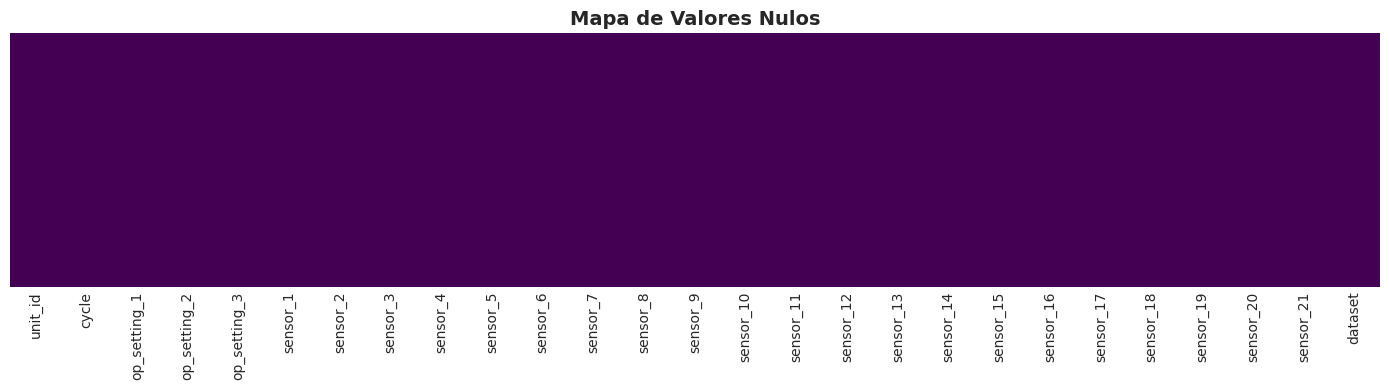

In [9]:
# Mapa visual de valores nulos
plt.figure(figsize=(14, 4))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Mapa de Valores Nulos', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 🎯 PASO 4 — Creación de la Variable Objetivo: RUL
**RUL (Remaining Useful Life)** = Ciclos restantes antes de que falle el motor.

Se calcula como: `RUL = ciclo_máximo_del_motor - ciclo_actual`

🎯 VARIABLE OBJETIVO — RUL
RUL mínimo: 0 ciclos  (motor a punto de fallar)
RUL máximo: 542 ciclos
RUL promedio: 122.33 ciclos

Total columnas ahora: 28
Total filas: 160,359


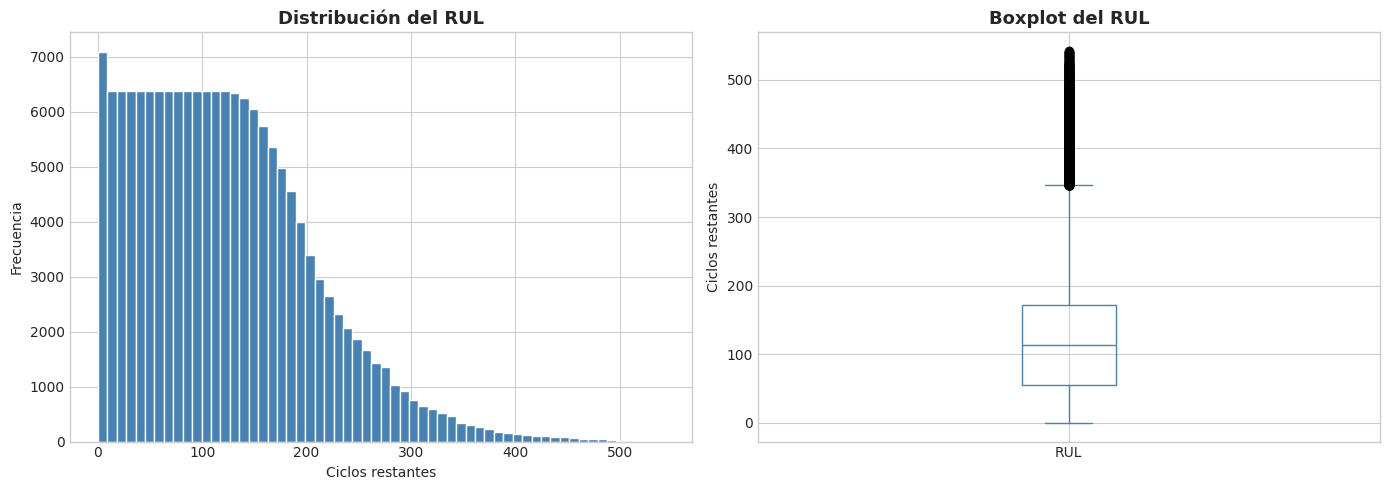

In [10]:
# Calcular RUL
max_cycles = df.groupby(['dataset', 'unit_id'])['cycle'].max().reset_index()
max_cycles.columns = ['dataset', 'unit_id', 'max_cycle']
df = df.merge(max_cycles, on=['dataset', 'unit_id'])
df['RUL'] = df['max_cycle'] - df['cycle']
df = df.drop(columns=['max_cycle'])

print('=' * 50)
print('🎯 VARIABLE OBJETIVO — RUL')
print('=' * 50)
print(f'RUL mínimo: {df["RUL"].min()} ciclos  (motor a punto de fallar)')
print(f'RUL máximo: {df["RUL"].max()} ciclos')
print(f'RUL promedio: {df["RUL"].mean():.2f} ciclos')
print(f'\nTotal columnas ahora: {df.shape[1]}')
print(f'Total filas: {df.shape[0]:,}')

# Distribución del RUL
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['RUL'], bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('Distribución del RUL', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Ciclos restantes')
axes[0].set_ylabel('Frecuencia')

df['RUL'].plot(kind='box', ax=axes[1], color='steelblue')
axes[1].set_title('Boxplot del RUL', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Ciclos restantes')

plt.tight_layout()
plt.show()

---
## 📊 PASO 5 — Distribución de Variables Numéricas

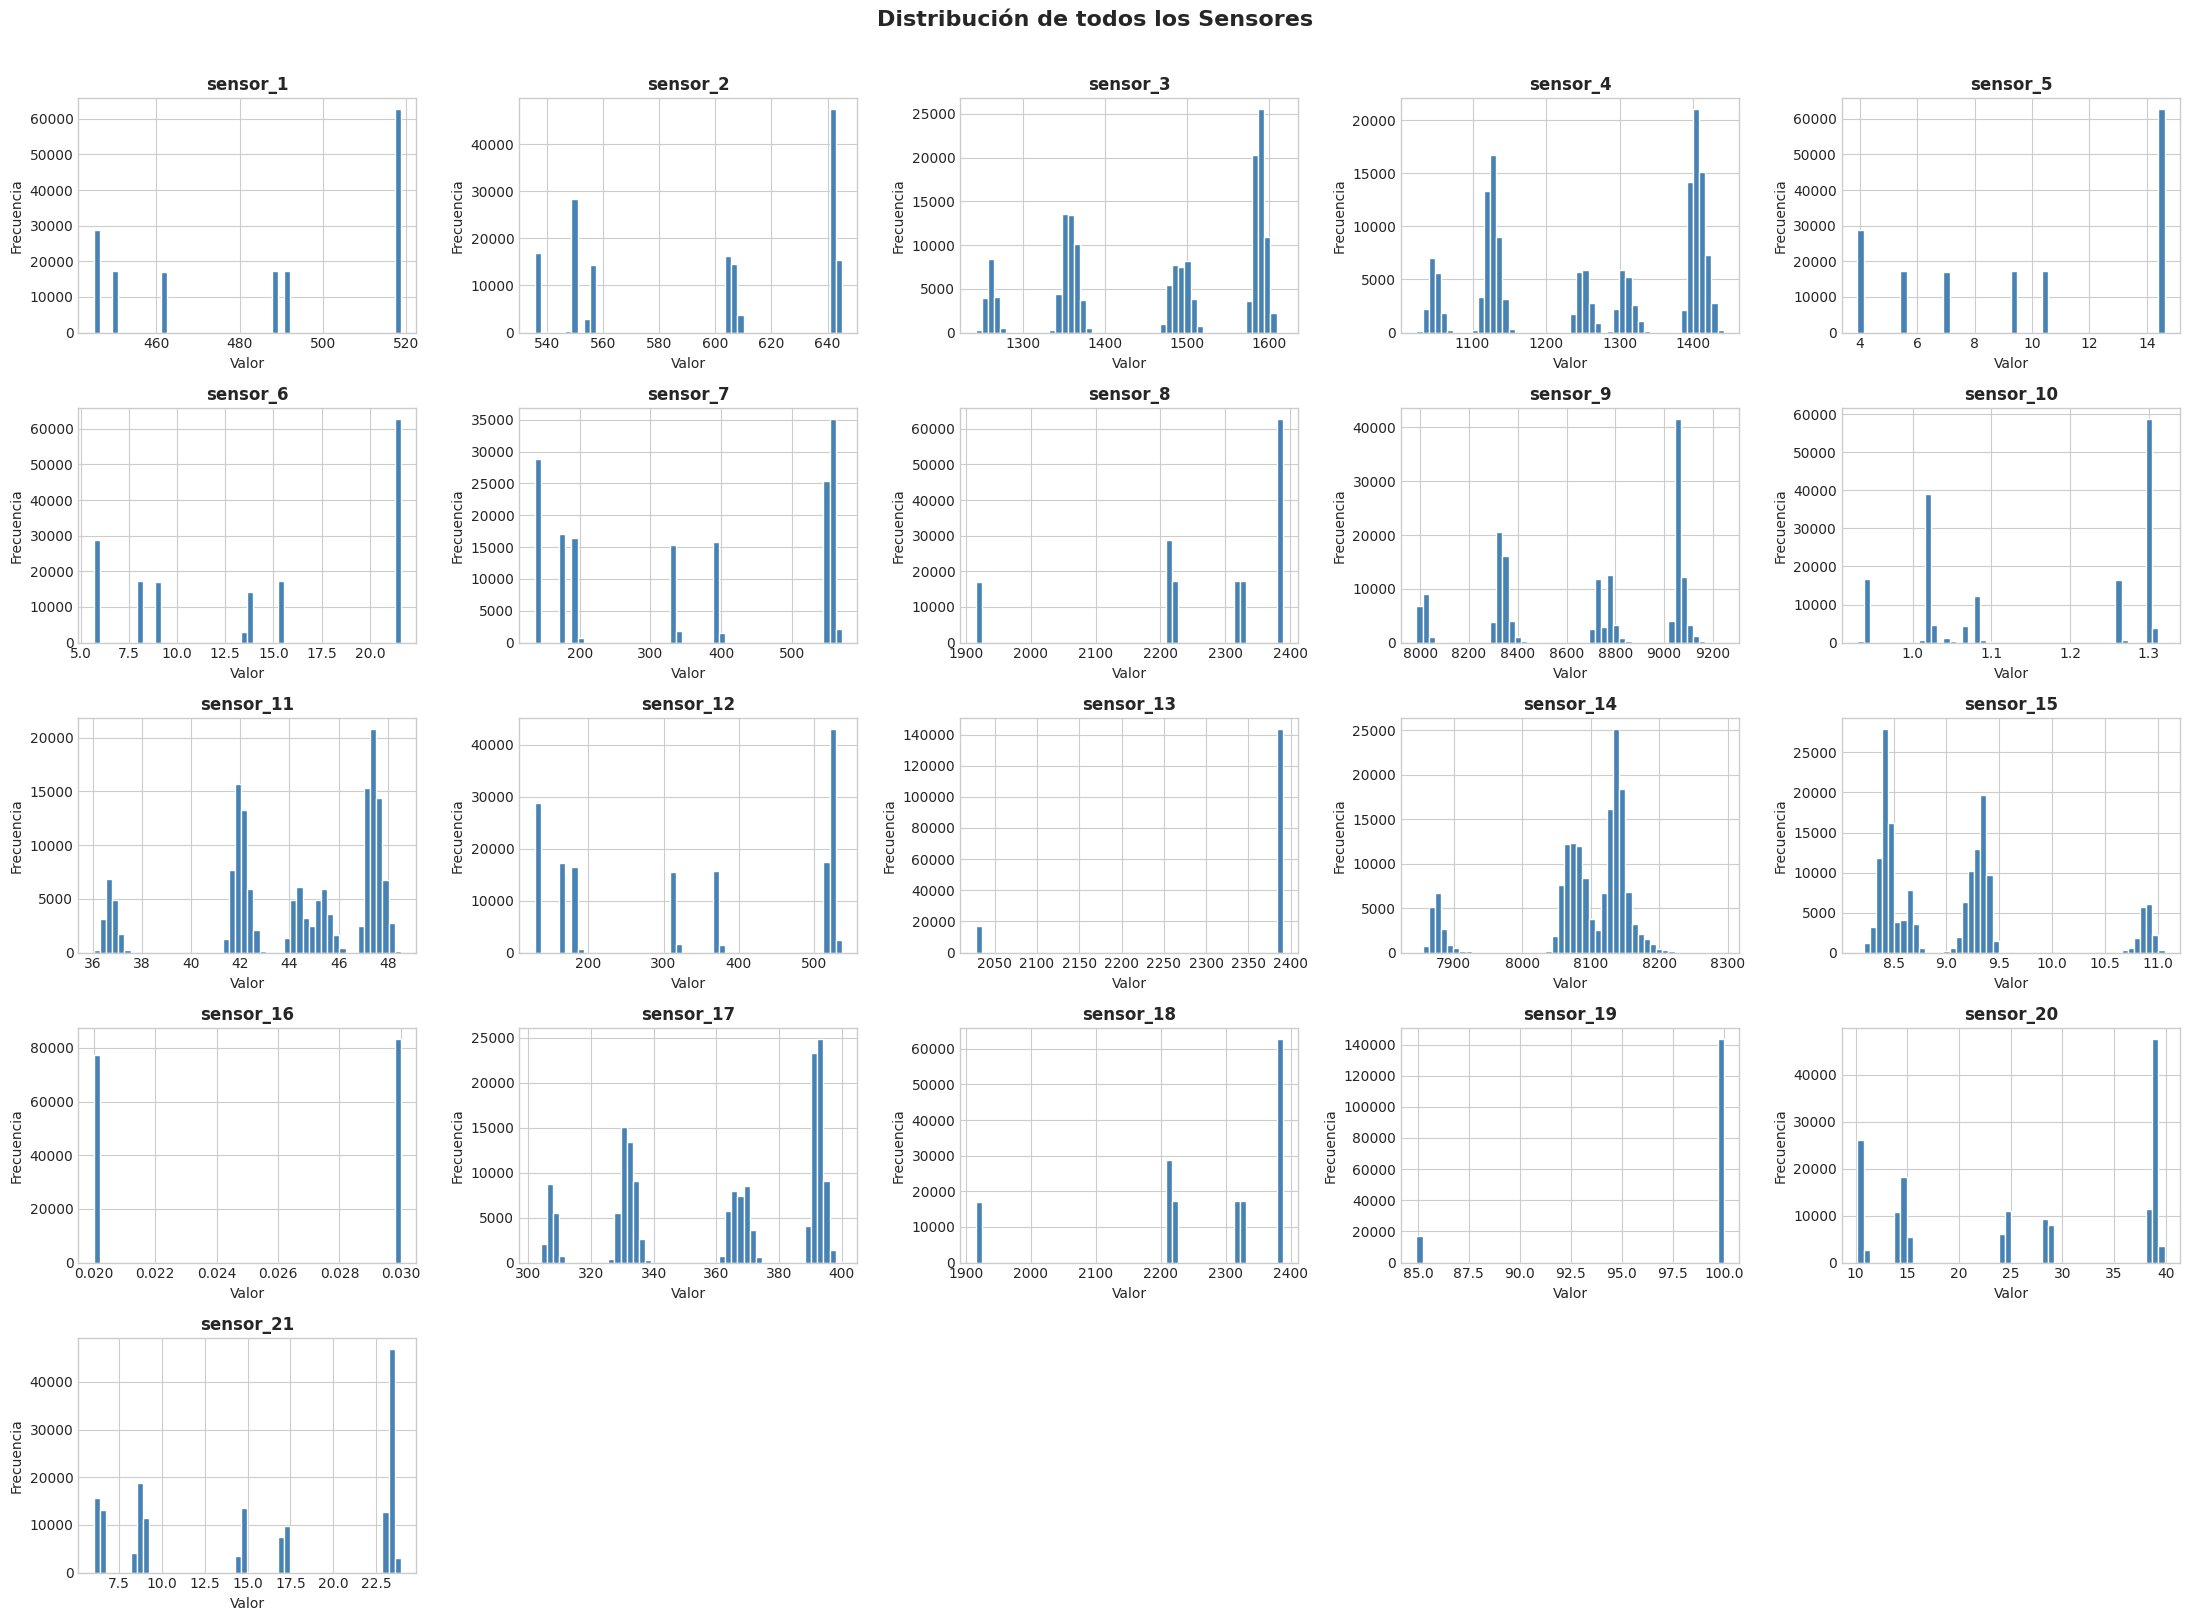

In [11]:
sensores = [f'sensor_{i}' for i in range(1, 22)]

# Distribución de todos los sensores
fig, axes = plt.subplots(5, 5, figsize=(22, 16))
axes = axes.flatten()

for i, sensor in enumerate(sensores):
    axes[i].hist(df[sensor], bins=50, color='steelblue', edgecolor='white')
    axes[i].set_title(sensor, fontweight='bold')
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Frecuencia')

for j in range(len(sensores), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribución de todos los Sensores', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

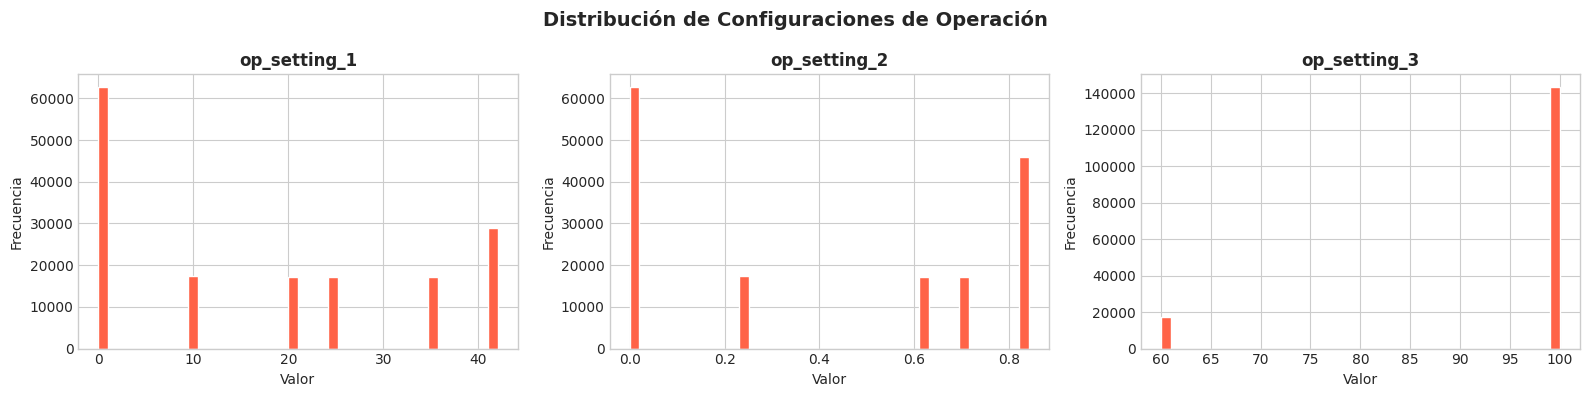

In [12]:
# Distribución de configuraciones de operación
operaciones = ['op_setting_1', 'op_setting_2', 'op_setting_3']

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for i, op in enumerate(operaciones):
    axes[i].hist(df[op], bins=40, color='tomato', edgecolor='white')
    axes[i].set_title(op, fontweight='bold')
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Frecuencia')

plt.suptitle('Distribución de Configuraciones de Operación', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 🎯 PASO 6 — Selección de Variables Predictoras
Identificamos qué sensores tienen poca varianza (casi constantes) y no aportan al modelo.

📊 Varianza de cada sensor:
sensor_16         0.000025
sensor_10         0.020193
sensor_15         0.564874
sensor_11        11.739821
sensor_5         18.194955
sensor_19        21.680849
sensor_6         41.524136
sensor_21        49.211164
sensor_20       136.689346
sensor_1        925.400015
sensor_17       962.329127
sensor_2       1804.424361
sensor_14      6500.109571
sensor_13     12358.155761
sensor_3      13965.392208
sensor_4      18577.709837
sensor_8      20285.340176
sensor_18     20309.987770
sensor_12     26959.499018
sensor_7      30322.592497
sensor_9     140368.207553
dtype: float64


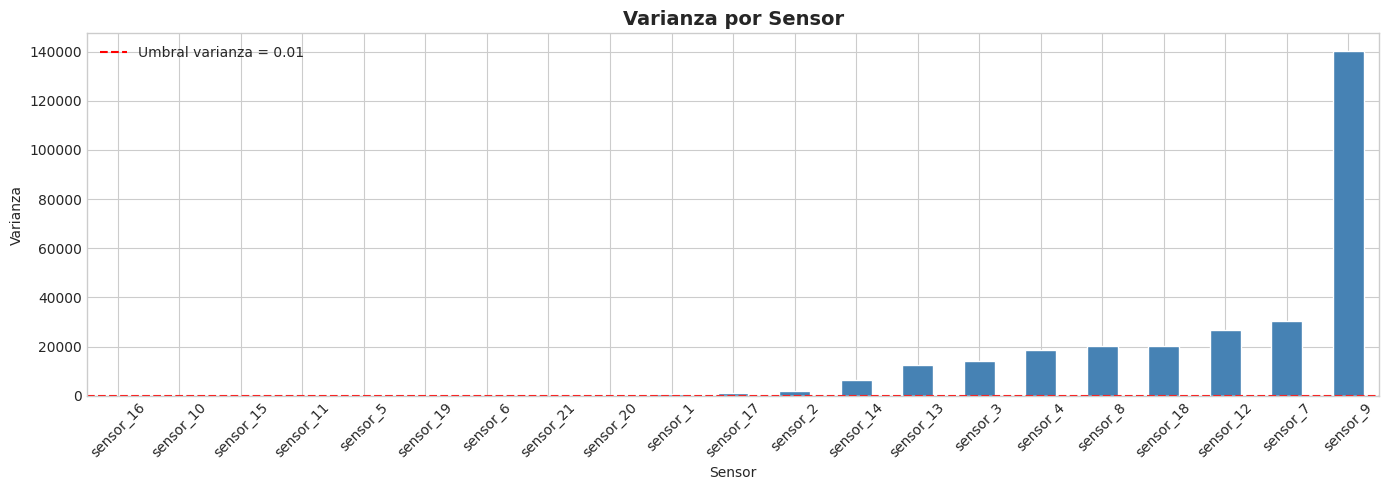


❌ Sensores con varianza baja (descartar): ['sensor_16']

✅ Sensores útiles para el modelo (20): ['sensor_10', 'sensor_15', 'sensor_11', 'sensor_5', 'sensor_19', 'sensor_6', 'sensor_21', 'sensor_20', 'sensor_1', 'sensor_17', 'sensor_2', 'sensor_14', 'sensor_13', 'sensor_3', 'sensor_4', 'sensor_8', 'sensor_18', 'sensor_12', 'sensor_7', 'sensor_9']


In [13]:
# Calcular varianza de cada sensor
varianza = df[sensores].var().sort_values()

print('📊 Varianza de cada sensor:')
print(varianza.round(6))

# Gráfica de varianza
plt.figure(figsize=(14, 5))
varianza.plot(kind='bar', color='steelblue', edgecolor='white')
plt.axhline(y=0.01, color='red', linestyle='--', label='Umbral varianza = 0.01')
plt.title('Varianza por Sensor', fontsize=14, fontweight='bold')
plt.xlabel('Sensor')
plt.ylabel('Varianza')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# Identificar sensores útiles y a descartar
umbral = 0.01
sensores_bajos = varianza[varianza < umbral].index.tolist()
sensores_utiles = varianza[varianza >= umbral].index.tolist()

print(f'\n❌ Sensores con varianza baja (descartar): {sensores_bajos}')
print(f'\n✅ Sensores útiles para el modelo ({len(sensores_utiles)}): {sensores_utiles}')

In [14]:
# Resumen final de variables
features = ['cycle', 'op_setting_1', 'op_setting_2', 'op_setting_3'] + sensores_utiles

print('=' * 55)
print('📋 RESUMEN DE VARIABLES PARA EL MODELO')
print('=' * 55)
print(f'\n🎯 Variable Objetivo:')
print(f'   → RUL (Remaining Useful Life)')
print(f'\n📊 Variables Predictoras ({len(features)}):')
for f in features:
    print(f'   → {f}')
print(f'\n❌ Variables descartadas:')
print(f'   → unit_id (identificador, no aporta)')
print(f'   → dataset (etiqueta interna)')
for s in sensores_bajos:
    print(f'   → {s} (varianza muy baja)')

📋 RESUMEN DE VARIABLES PARA EL MODELO

🎯 Variable Objetivo:
   → RUL (Remaining Useful Life)

📊 Variables Predictoras (24):
   → cycle
   → op_setting_1
   → op_setting_2
   → op_setting_3
   → sensor_10
   → sensor_15
   → sensor_11
   → sensor_5
   → sensor_19
   → sensor_6
   → sensor_21
   → sensor_20
   → sensor_1
   → sensor_17
   → sensor_2
   → sensor_14
   → sensor_13
   → sensor_3
   → sensor_4
   → sensor_8
   → sensor_18
   → sensor_12
   → sensor_7
   → sensor_9

❌ Variables descartadas:
   → unit_id (identificador, no aporta)
   → dataset (etiqueta interna)
   → sensor_16 (varianza muy baja)


---
## 🔗 PASO 7 — Correlación entre Variables

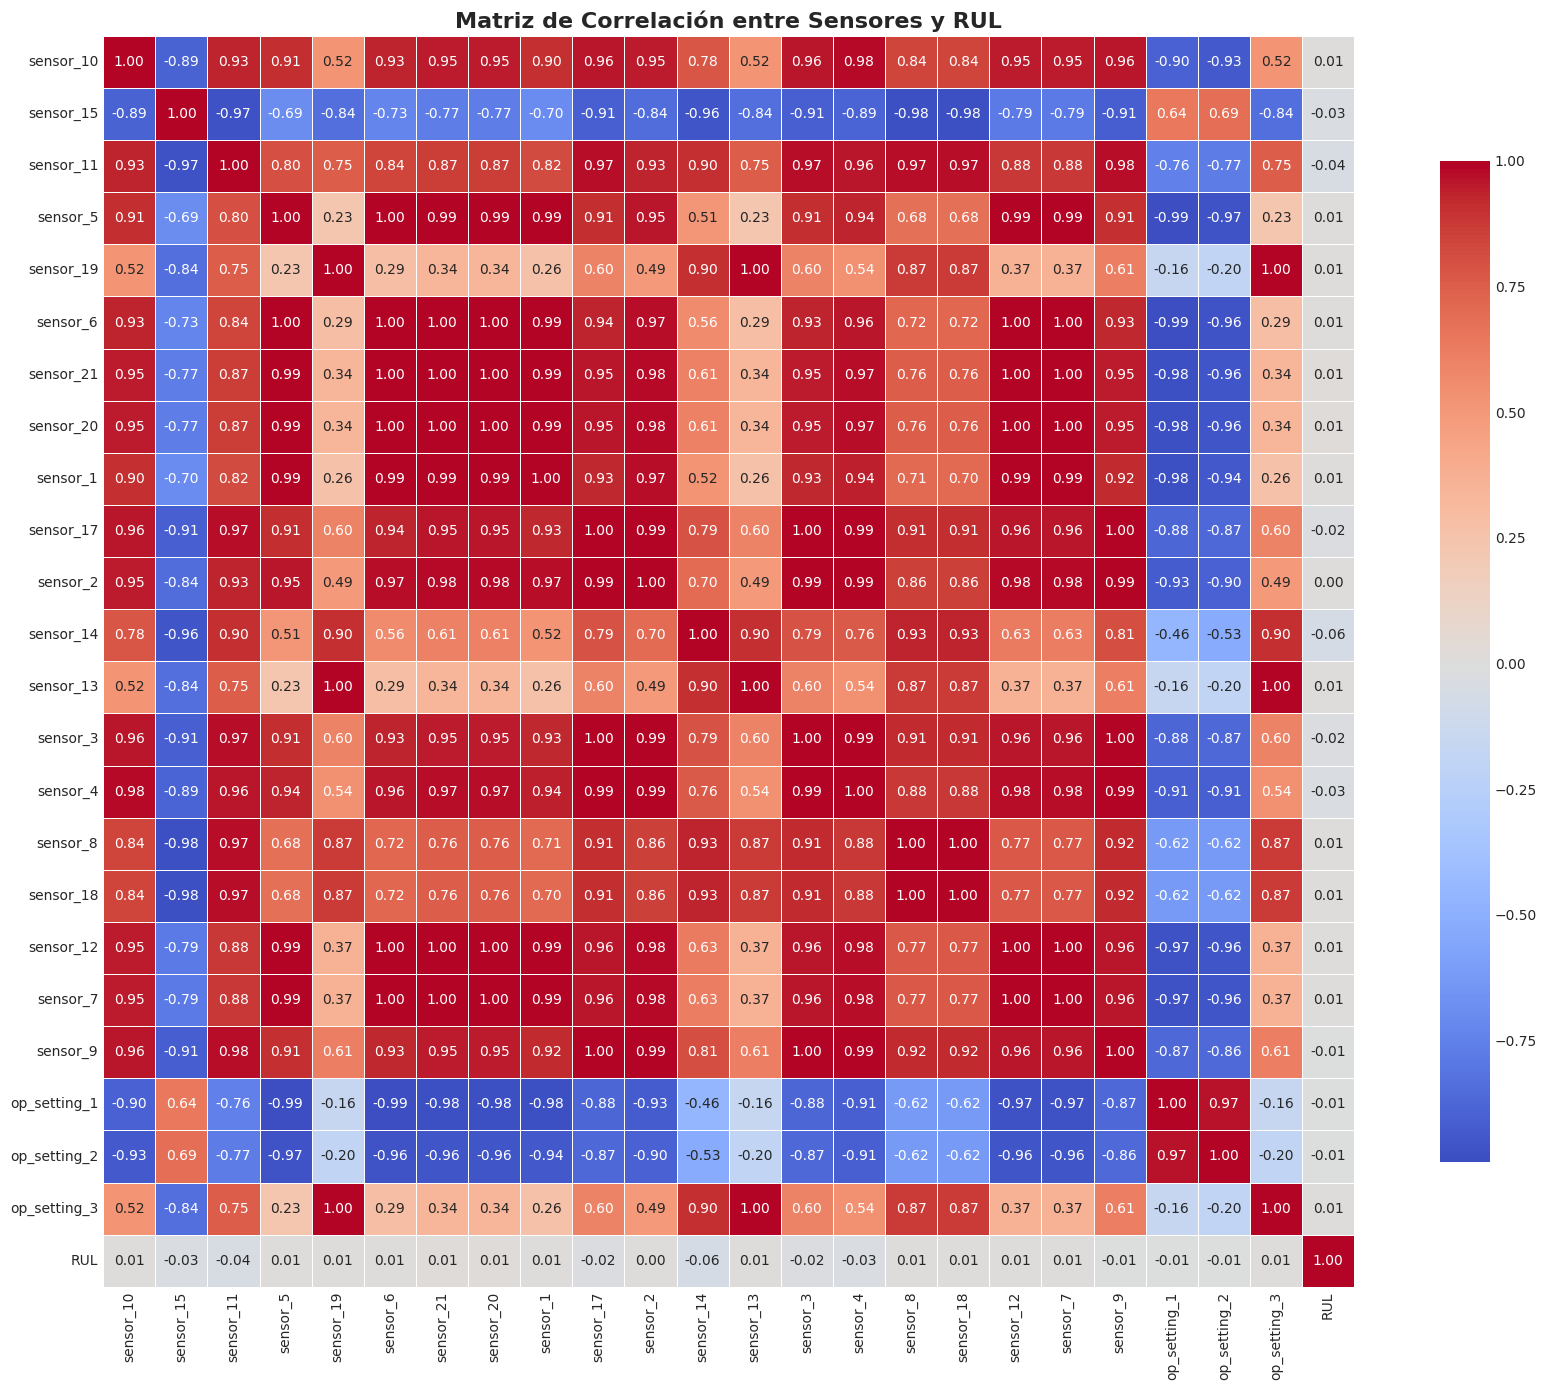

In [15]:
cols_corr = sensores_utiles + ['op_setting_1', 'op_setting_2', 'op_setting_3', 'RUL']
corr_matrix = df[cols_corr].corr()

# Heatmap completo
plt.figure(figsize=(18, 14))
sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={'shrink': 0.8})
plt.title('Matriz de Correlación entre Sensores y RUL', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

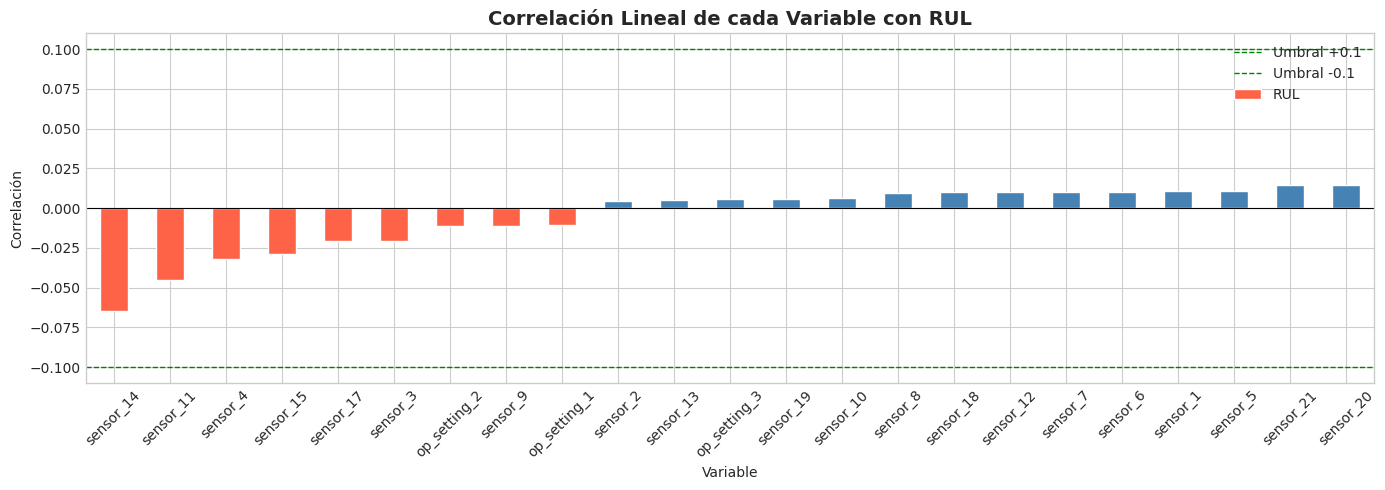

🔝 Top 10 variables más correlacionadas con RUL:
sensor_14       0.064813
sensor_11       0.044859
sensor_4        0.032047
sensor_15       0.028528
sensor_17       0.020581
sensor_3        0.020455
sensor_20       0.014697
sensor_21       0.014656
op_setting_2    0.011275
sensor_9        0.011261
Name: RUL, dtype: float64

⚠️ Nota: La correlación lineal es baja, pero el modelo Random Forest
   captura relaciones NO LINEALES entre sensores y RUL.


In [16]:
# Correlación específica con RUL
corr_rul = corr_matrix['RUL'].drop('RUL').sort_values()

plt.figure(figsize=(14, 5))
corr_rul.plot(kind='bar',
              color=['tomato' if x < 0 else 'steelblue' for x in corr_rul],
              edgecolor='white')
plt.title('Correlación Lineal de cada Variable con RUL', fontsize=14, fontweight='bold')
plt.axhline(y=0, color='black', linewidth=0.8)
plt.axhline(y=0.1, color='green', linestyle='--', linewidth=1, label='Umbral +0.1')
plt.axhline(y=-0.1, color='green', linestyle='--', linewidth=1, label='Umbral -0.1')
plt.xlabel('Variable')
plt.ylabel('Correlación')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print('🔝 Top 10 variables más correlacionadas con RUL:')
print(corr_rul.abs().sort_values(ascending=False).head(10))
print('\n⚠️ Nota: La correlación lineal es baja, pero el modelo Random Forest')
print('   captura relaciones NO LINEALES entre sensores y RUL.')

---
## 📈 PASO 8 — Evolución de Sensores por Ciclo
Visualizamos cómo cambian los sensores más importantes a medida que el motor se acerca a la falla.

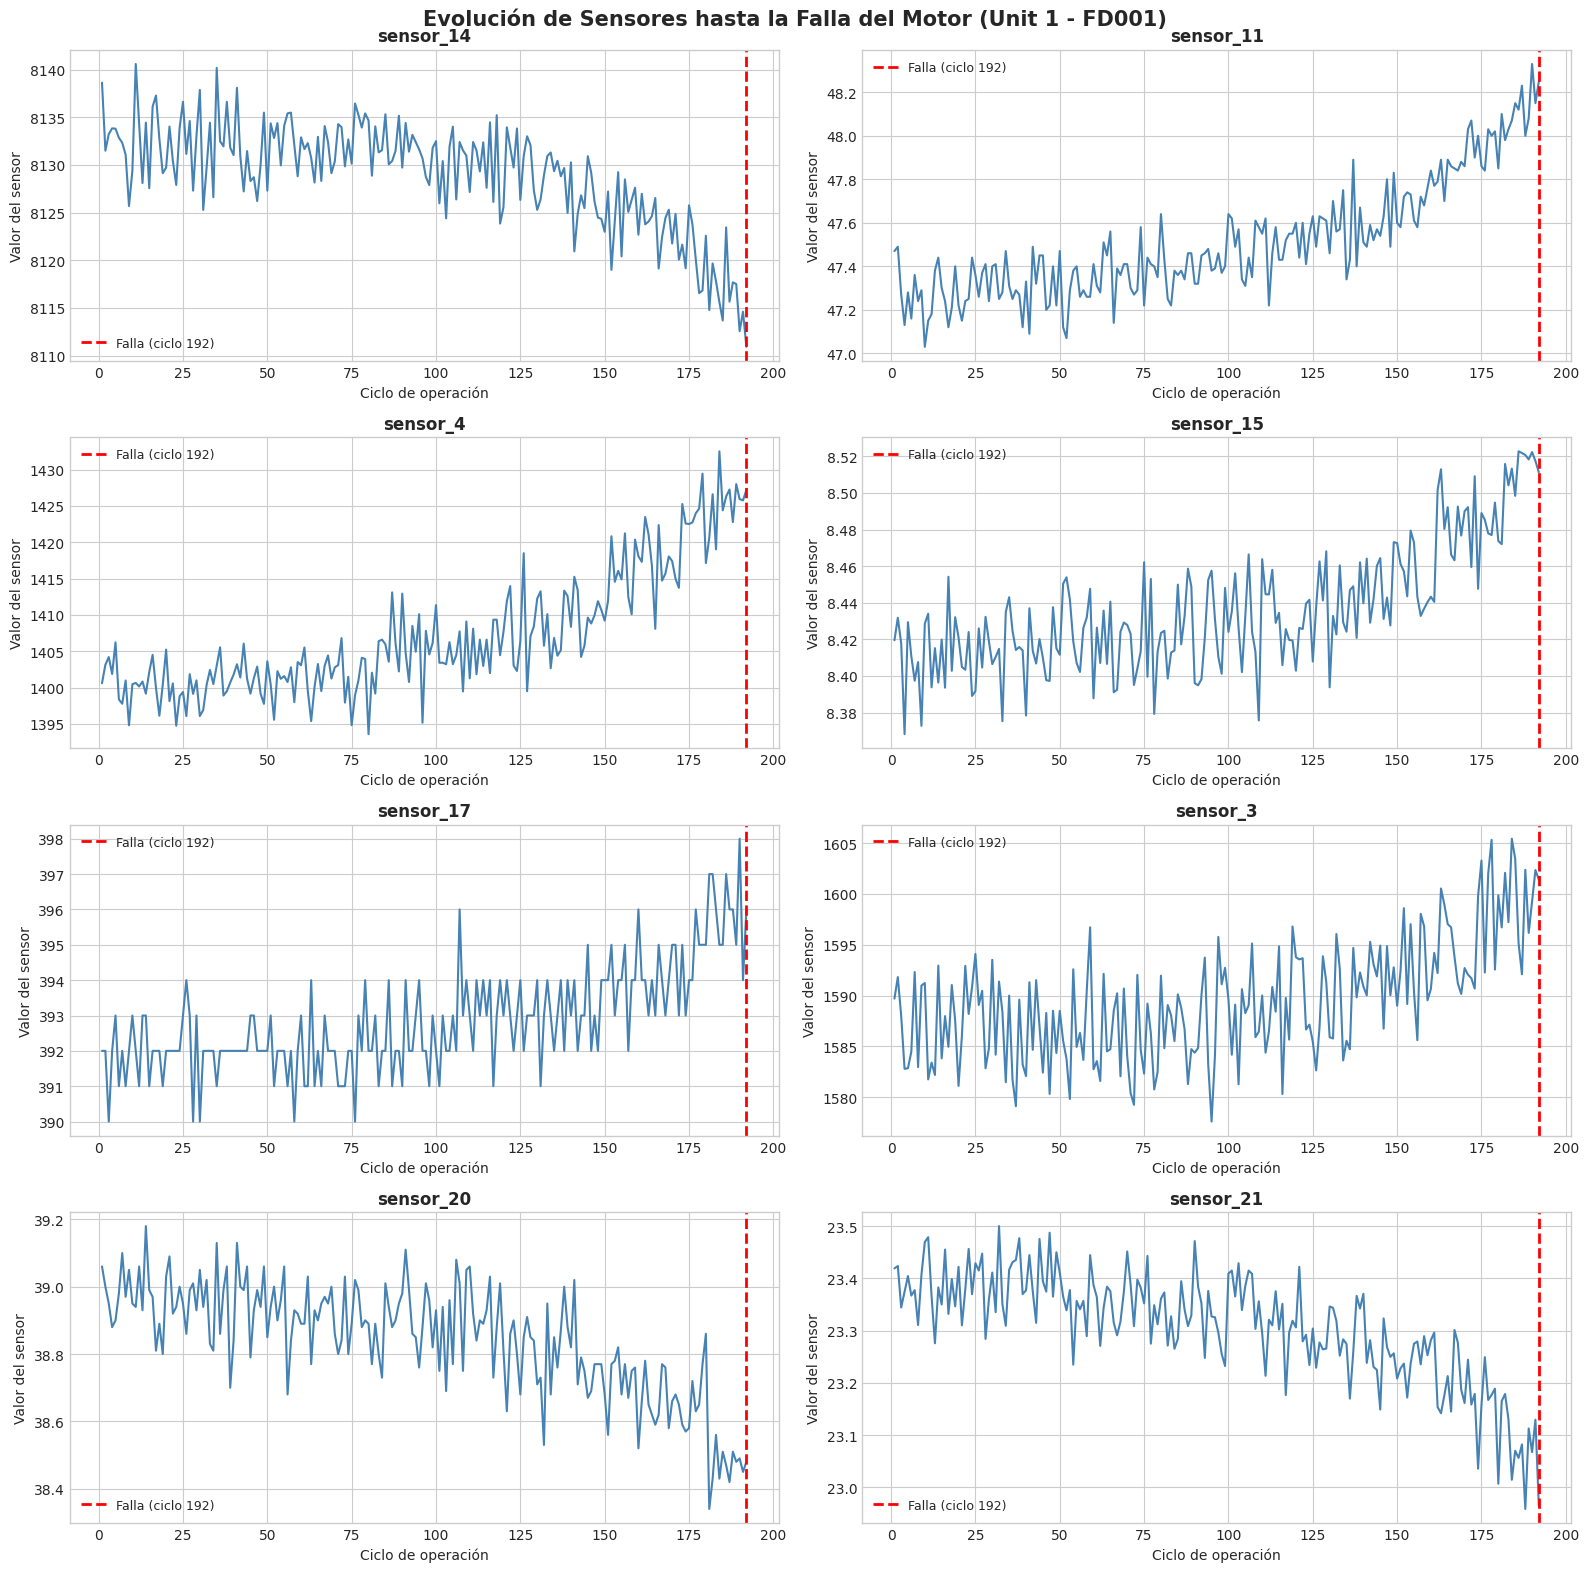

In [17]:
# Seleccionar un motor representativo
motor = df[(df['unit_id'] == 1) & (df['dataset'] == 'FD001')].copy()
ciclo_falla = motor['cycle'].max()

# Top 8 sensores más correlacionados con RUL
sensores_top = corr_rul.abs().sort_values(ascending=False).head(8).index.tolist()

fig, axes = plt.subplots(4, 2, figsize=(16, 16))
axes = axes.flatten()

for i, sensor in enumerate(sensores_top):
    axes[i].plot(motor['cycle'], motor[sensor], color='steelblue', linewidth=1.5)
    axes[i].axvline(x=ciclo_falla, color='red', linestyle='--', linewidth=2, label=f'Falla (ciclo {ciclo_falla})')
    axes[i].set_title(f'{sensor}', fontweight='bold', fontsize=12)
    axes[i].set_xlabel('Ciclo de operación')
    axes[i].set_ylabel('Valor del sensor')
    axes[i].legend(fontsize=9)

plt.suptitle('Evolución de Sensores hasta la Falla del Motor (Unit 1 - FD001)',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

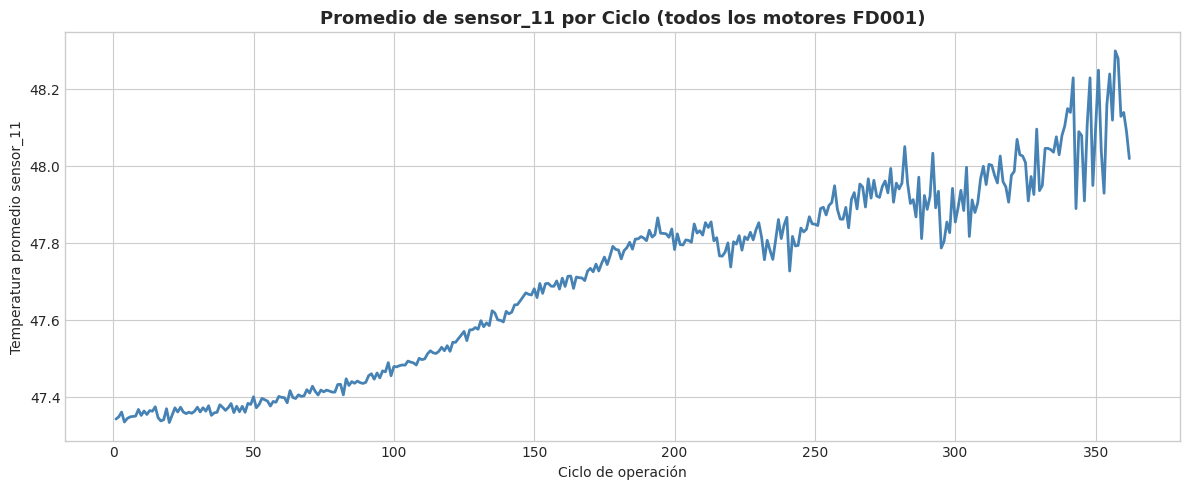

In [18]:
# Comparar múltiples motores — promedio de sensor_11 por ciclo
df_fd001 = df[df['dataset'] == 'FD001'].copy()

# Normalizar ciclos al revés (0 = falla, negativo = ciclos antes de la falla)
promedio_sensor = df_fd001.groupby('cycle')['sensor_11'].mean()

plt.figure(figsize=(12, 5))
plt.plot(promedio_sensor.index, promedio_sensor.values, color='steelblue', linewidth=2)
plt.title('Promedio de sensor_11 por Ciclo (todos los motores FD001)',
          fontsize=13, fontweight='bold')
plt.xlabel('Ciclo de operación')
plt.ylabel('Temperatura promedio sensor_11')
plt.tight_layout()
plt.show()

---
## 📝 PASO 9 — Resumen y Conclusiones del EDA

In [19]:
print('=' * 60)
print('📝 RESUMEN FINAL DEL EDA')
print('=' * 60)

print(f'''
📊 DATASET:
   → Fuente: NASA CMAPSS Turbofan Engine Dataset
   → Filas totales: {df.shape[0]:,}
   → Columnas totales: {df.shape[1]}
   → Valores nulos: 0

🎯 VARIABLE OBJETIVO:
   → RUL (Remaining Useful Life)
   → Rango: 0 a {df['RUL'].max()} ciclos
   → Promedio: {df['RUL'].mean():.1f} ciclos

📊 VARIABLES PREDICTORAS:
   → {len(features)} variables en total
   → cycle + 3 configuraciones + {len(sensores_utiles)} sensores útiles
   → {len(sensores_bajos)} sensores descartados por baja varianza: {sensores_bajos}

🔍 HALLAZGOS CLAVE:
   → Correlación lineal baja con RUL (max ~0.06)
     → La relación es NO LINEAL, ideal para Random Forest
   → Sensores más importantes: sensor_14, sensor_11, sensor_4
   → Los sensores muestran degradación gradual hasta la falla
   → Alta correlación entre sensores (redundancia)

✅ PRÓXIMO PASO:
   → Entrenar modelo Random Forest para predecir RUL
   → Aplicar RUL cap = 125 para mejorar el modelo
   → Objetivo: R² > 0.85
''')

print('=' * 60)
print('✅ EDA COMPLETO')
print('=' * 60)

📝 RESUMEN FINAL DEL EDA

📊 DATASET:
   → Fuente: NASA CMAPSS Turbofan Engine Dataset
   → Filas totales: 160,359
   → Columnas totales: 28
   → Valores nulos: 0

🎯 VARIABLE OBJETIVO:
   → RUL (Remaining Useful Life)
   → Rango: 0 a 542 ciclos
   → Promedio: 122.3 ciclos

📊 VARIABLES PREDICTORAS:
   → 24 variables en total
   → cycle + 3 configuraciones + 20 sensores útiles
   → 1 sensores descartados por baja varianza: ['sensor_16']

🔍 HALLAZGOS CLAVE:
   → Correlación lineal baja con RUL (max ~0.06)
     → La relación es NO LINEAL, ideal para Random Forest
   → Sensores más importantes: sensor_14, sensor_11, sensor_4
   → Los sensores muestran degradación gradual hasta la falla
   → Alta correlación entre sensores (redundancia)

✅ PRÓXIMO PASO:
   → Entrenar modelo Random Forest para predecir RUL
   → Aplicar RUL cap = 125 para mejorar el modelo
   → Objetivo: R² > 0.85

✅ EDA COMPLETO
